# sink removal experiments

this notebook tests what happens when the attention sink tokens are removed from the mesh transformer during generation.

experiments in this notebook:
- remove the bos token and generate without it
- replace the first triangle with neutral coordinates
- compare attention patterns with and without the sink
- repeat across several seeds

background: barbero et al 2025 report that removing the sink should raise attention entropy, spread attention more evenly across positions, and can degrade output quality.

## setup

- purpose: load the libraries, set the device, and load the meshxl chair model that every experiment uses
- method: load the chair checkpoint with `strict=False` so the extra checkpoint keys do not stop the load
- output: prints the device and the bos and eos token ids

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from models.mesh_xl.get_model import MeshXL
from models.mesh_xl.tokenizer import undiscretize
from types import SimpleNamespace
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

# use gpu if present, else cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

/home/wkt7ne/miniforge3/envs/meshxl/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [2]:
# model settings: base llm, coordinate levels, max triangle count
config = SimpleNamespace(
    llm='mesh-xl/mesh-xl-1.3b',
    n_discrete_size=128,
    n_max_triangles=800
)

# build the model and move it to the device
model = MeshXL(config)
model = model.to(device)
model.eval()

# load the pretrained chair weights, allow missing keys
checkpoint = torch.load('ckpts/meshxl-1.3b-chair.pth', map_location=device)
model.load_state_dict(checkpoint['model'], strict=False)

print(f'model loaded')
print(f'bos token id: {model.bos_token_id}')
print(f'eos token id: {model.eos_token_id}')

Some weights of the model checkpoint at mesh-xl/mesh-xl-1.3b were not used when initializing OPTForCausalLM: ['tokenizer.dummpy_param', 'transformer.lm_head.weight']
- This IS expected if you are initializing OPTForCausalLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing OPTForCausalLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


model loaded
bos token id: 128
eos token id: 129


## helper functions

- purpose: define the token to mesh, rotation, and plotting functions reused by every experiment
- method:
  - `tokens_to_mesh` groups tokens into triangles and calls `undiscretize` with `continuous_range=(-1, 1)` and `num_discrete=128` to map token ids back to coordinates
  - `apply_rotation` reorders the axes to `[0, 2, 1]` and flips the new y axis to stand the chair upright
  - `plot_mesh` draws the triangles as a `Poly3DCollection` and scales the axis limits to the largest vertex magnitude
- output: prints a line confirming the functions are defined

In [3]:
def tokens_to_mesh(tokens):
    """
    convert a token sequence to mesh vertices and faces
    """
    # accept numpy or list input as a tensor
    if isinstance(tokens, np.ndarray):
        tokens = torch.tensor(tokens)
    elif isinstance(tokens, list):
        tokens = torch.tensor(tokens)

    num_triangles = len(tokens) // 9  # 9 tokens per triangle
    # return empty arrays when there is no full triangle
    if num_triangles == 0:
        return np.array([]).reshape(0, 3), np.array([]).reshape(0, 3).astype(int)

    tokens = tokens[:num_triangles * 9]  # drop a trailing partial triangle
    tokens = tokens.reshape(num_triangles, 3, 3)  # triangles by 3 vertices by xyz

    # map token ids back to coordinates in the range -1 to 1 over 128 bins
    coordinates = undiscretize(tokens, continuous_range=(-1., 1.), num_discrete=128)
    vertices = coordinates.reshape(-1, 3).cpu().numpy()  # flat list of vertices
    faces = np.arange(len(vertices)).reshape(-1, 3)  # every 3 vertices form a face

    return vertices, faces


def apply_rotation(vertices):
    """
    rotate vertices so the chair displays upright
    """
    if len(vertices) == 0:
        return vertices
    rotated = vertices.copy()
    rotated = rotated[:, [0, 2, 1]]  # swap y and z
    rotated[:, 1] *= -1  # flip the new y
    return rotated


def plot_mesh(vertices, faces, title='mesh', ax=None):
    """
    draw a 3d mesh from vertices and faces
    """
    # make a new axis when none is passed
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')

    # mark an empty mesh and stop
    if len(vertices) == 0:
        ax.set_title(f'{title} (empty)')
        return ax

    vertices = apply_rotation(vertices)  # rotate to upright

    # build the triangle surface
    mesh = Poly3DCollection([vertices[face] for face in faces],
                            alpha=0.8, edgecolor='black', linewidth=0.1)
    mesh.set_facecolor('steelblue')
    ax.add_collection3d(mesh)

    # scale the axes to the largest vertex magnitude
    max_range = np.abs(vertices).max()
    ax.set_xlim(-max_range, max_range)
    ax.set_ylim(-max_range, max_range)
    ax.set_zlim(-max_range, max_range)
    ax.set_title(title)

    return ax


print('helper functions defined')

helper functions defined


## baseline generation with bos

- purpose: define the generation loop and produce the reference mesh that starts from the bos token
- method:
  - `generate_mesh` decodes one token at a time, at each step turns the last position logits into probabilities, records the entropy as `-sum(p log p)`, and samples the next token with `torch.multinomial`, so decoding is stochastic under a fixed seed
  - the baseline run starts from `[bos]` with seed 42
- output: prints the token and triangle counts of the baseline mesh and stores the per step entropy

In [4]:
def generate_mesh(model, device, start_tokens=None, max_triangles=200, seed=42):
    """
    generate mesh tokens one at a time
    input:
        start_tokens: tokens to begin from, default is [bos]
        max_triangles: cap on triangles, times 9 gives the token cap
        seed: fixes the sampling so a run repeats
    output:
        generated_tokens: the sampled tokens without the start tokens
        logits_entropy: entropy of the next token distribution at each step
    """
    torch.manual_seed(seed)  # fix sampling

    # default start is the bos token alone
    if start_tokens is None:
        start_tokens = [model.bos_token_id]

    context = torch.tensor([start_tokens], device=device)  # current sequence
    max_tokens = max_triangles * 9

    generated_tokens = []
    logits_entropy = []

    with torch.no_grad():
        for step in tqdm(range(max_tokens), desc='generating'):
            outputs = model.transformer(input_ids=context)

            # next token distribution from the last position
            final_logits = outputs.logits[0, -1, :]
            final_probs = F.softmax(final_logits, dim=-1)

            # entropy of that distribution, higher means less certain
            entropy = -torch.sum(final_probs * torch.log(final_probs + 1e-10)).item()
            logits_entropy.append(entropy)

            # sample the next token from the distribution
            next_token = torch.multinomial(final_probs, 1).item()
            generated_tokens.append(next_token)

            # stop on the end token
            if next_token == model.eos_token_id:
                print(f'eos at step {step}')
                break

            # append the new token and continue
            context = torch.cat([
                context,
                torch.tensor([[next_token]], device=device)
            ], dim=1)

    return generated_tokens, logits_entropy


print('generation function defined')

generation function defined


In [5]:
# baseline run starts from the bos token
# cache to disk so a rerun does not regenerate for an hour
import os
import pickle

baseline_cache = 'baseline_tokens_1000.pkl'

if os.path.exists(baseline_cache):
    with open(baseline_cache, 'rb') as f:
        baseline_tokens, baseline_entropy = pickle.load(f)
    print(f'loaded baseline from cache ({len(baseline_tokens) // 9} triangles)')
else:
    print('generating baseline mesh with bos token...')
    baseline_tokens, baseline_entropy = generate_mesh(
        model, device,
        start_tokens=[model.bos_token_id],
        max_triangles=1000,
        seed=42
    )
    with open(baseline_cache, 'wb') as f:
        pickle.dump((baseline_tokens, baseline_entropy), f)
    print(f'generated {len(baseline_tokens)} tokens ({len(baseline_tokens) // 9} triangles)')

generating baseline mesh with bos token...


generating:  40%|████      | 3636/9000 [31:36<46:37,  1.92it/s]  

eos at step 3636
generated 3637 tokens (404 triangles)


## experiment 1: remove the bos token

- purpose: generate a mesh without the bos token and compare it to the baseline
- method:
  - the no bos run starts from the baseline first triangle `baseline_tokens[:9]` instead of `[bos]`, so generation has no sink at position 0
  - the two meshes are drawn side by side, and the per step entropy of both runs is plotted over the shared step range
- output: two saved pngs and printed mean entropy for both runs with the percent increase

In [6]:
# no bos run starts from the baseline first triangle instead of the bos token
print('generating mesh without bos token')

# start from the first 9 baseline tokens so position 0 is not the sink
no_bos_tokens, no_bos_entropy = generate_mesh(
    model, device,
    start_tokens=baseline_tokens[:9],
    max_triangles=1000,
    seed=42
)
print(f'generated {len(no_bos_tokens)} tokens ({len(no_bos_tokens) // 9} triangles)')

generating mesh without bos token


generating:  47%|████▋     | 4222/9000 [46:11<52:16,  1.52it/s]  

eos at step 4222
generated 4223 tokens (469 triangles)


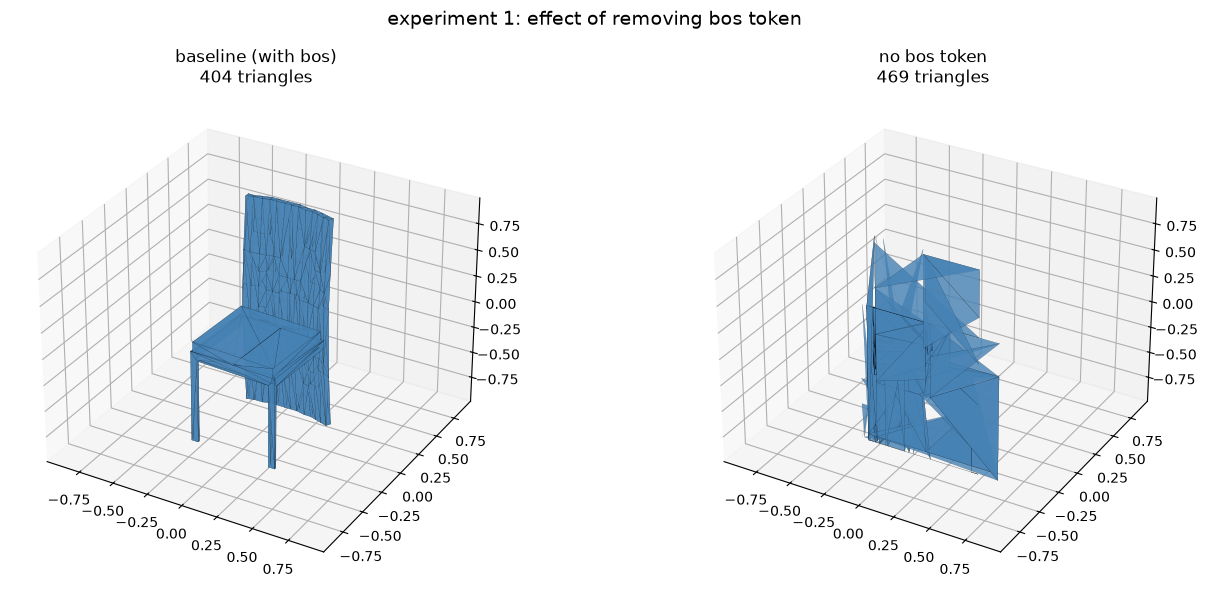

In [7]:
# draw the baseline and the no bos mesh side by side
fig = plt.figure(figsize=(14, 6))

# baseline mesh
ax1 = fig.add_subplot(121, projection='3d')
vertices1, faces1 = tokens_to_mesh(baseline_tokens)
plot_mesh(vertices1, faces1, title=f'baseline (with bos)\n{len(faces1)} triangles', ax=ax1)

# no bos mesh
ax2 = fig.add_subplot(122, projection='3d')
vertices2, faces2 = tokens_to_mesh(no_bos_tokens)
plot_mesh(vertices2, faces2, title=f'no bos token\n{len(faces2)} triangles', ax=ax2)

plt.suptitle('experiment 1: effect of removing bos token', fontsize=14)
plt.tight_layout()
plt.savefig('exp1_remove_bos_meshes.png', dpi=150)
plt.show()

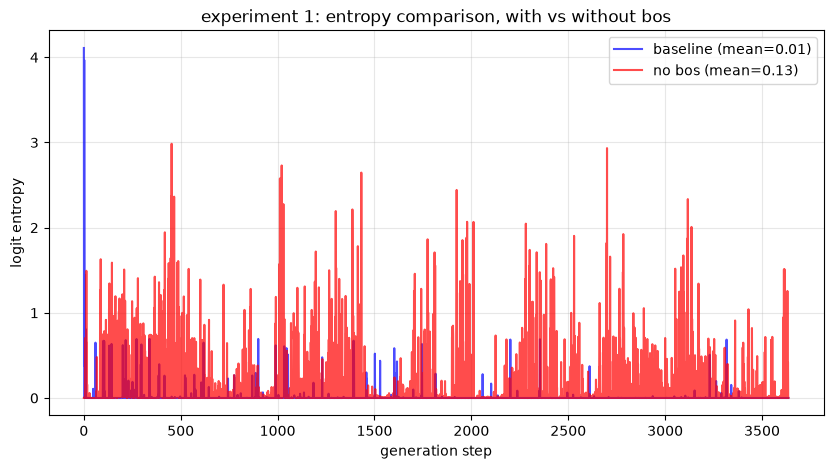

baseline mean entropy: 0.012
no bos mean entropy: 0.133
entropy increase: 1057.4%


In [8]:
# compare per step entropy of the two runs
plt.figure(figsize=(10, 5))

# use the shorter length so both lines align
min_len = min(len(baseline_entropy), len(no_bos_entropy))
steps = range(min_len)

plt.plot(steps, baseline_entropy[:min_len], 'b-', alpha=0.7, label=f'baseline (mean={np.mean(baseline_entropy[:min_len]):.2f})')
plt.plot(steps, no_bos_entropy[:min_len], 'r-', alpha=0.7, label=f'no bos (mean={np.mean(no_bos_entropy[:min_len]):.2f})')

plt.xlabel('generation step')
plt.ylabel('logit entropy')
plt.title('experiment 1: entropy comparison, with vs without bos')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('exp1_remove_bos_entropy.png', dpi=150)
plt.show()

print(f'baseline mean entropy: {np.mean(baseline_entropy):.3f}')
print(f'no bos mean entropy: {np.mean(no_bos_entropy):.3f}')
print(f'entropy increase: {(np.mean(no_bos_entropy) / np.mean(baseline_entropy) - 1) * 100:.1f}%')

## experiment 2: replace the first triangle

- purpose: test generation when the first triangle is set to neutral coordinates rather than a learned one
- method: the run starts from `[bos]` plus a first triangle of nine tokens all set to 64, the middle coordinate bin, then continues generation
- output: prints the token and triangle counts and draws the baseline next to the mesh built from the neutral first triangle

In [ ]:
# experiment 2 starts from a neutral first triangle instead of a learned one
print('generating mesh starting from triangle 2 (skipping first 2 triangles)...')

# nine tokens all set to 64, the middle coordinate bin
random_first_tri = [64, 64, 64, 64, 64, 64, 64, 64, 64]

# start from bos plus the neutral first triangle, then generate
skip_first_tokens, skip_first_entropy = generate_mesh(
    model, device,
    start_tokens=[model.bos_token_id] + random_first_tri,
    max_triangles=1000,
    seed=42
)

print(f'generated {len(skip_first_tokens)} tokens ({len(skip_first_tokens) // 9} triangles)')

generating mesh starting from triangle 2 (skipping first 2 triangles)...


generating:   8%|▊         | 738/9000 [00:58<20:37,  6.68it/s]

In [ ]:
# draw the baseline next to the neutral first triangle mesh
fig = plt.figure(figsize=(14, 6))

# baseline mesh
ax1 = fig.add_subplot(121, projection='3d')
vertices1, faces1 = tokens_to_mesh(baseline_tokens)
plot_mesh(vertices1, faces1, title=f'baseline\n{len(faces1)} triangles', ax=ax1)

# mesh including the neutral first triangle
ax2 = fig.add_subplot(122, projection='3d')
all_tokens = random_first_tri + skip_first_tokens
vertices2, faces2 = tokens_to_mesh(all_tokens)
plot_mesh(vertices2, faces2, title=f'random first triangle\n{len(faces2)} triangles', ax=ax2)

plt.suptitle('experiment 2: effect of random first triangle', fontsize=14)
plt.tight_layout()
plt.savefig('exp2_random_first_tri_meshes.png', dpi=150)
plt.show()

## experiment 3: attention patterns without the sink

- purpose: compare the attention of the last token with and without the bos sink
- method:
  - `get_attention_pattern` reads layer 23 attention, averages over heads, and returns the full matrix, and the last row is taken as what the final token attends to
  - the panels compare the two attention vectors, their attention entropy, and their gini coefficient, where gini measures how concentrated the attention is
- output: a saved png of four panels and printed attention entropy and gini for both runs

In [ ]:
def get_attention_pattern(model, device, tokens, layer_idx=23):
    """
    return the averaged attention matrix at one layer for a sequence
    """
    context = torch.tensor([tokens], device=device)

    with torch.no_grad():
        outputs = model.transformer(input_ids=context, output_attentions=True)

    # attention at the chosen layer, averaged over heads
    attn = outputs.attentions[layer_idx][0].mean(dim=0).cpu().numpy()

    return attn


# baseline attention over the first 100 triangles, last row is the final token
baseline_context = [model.bos_token_id] + baseline_tokens[:100*9]
baseline_attn_full = get_attention_pattern(model, device, baseline_context)
baseline_attn = baseline_attn_full[-1, :]

# no bos attention over the first 100 triangles
no_bos_context = random_start + no_bos_tokens[:100*9]
no_bos_attn_full = get_attention_pattern(model, device, no_bos_context)
no_bos_attn = no_bos_attn_full[-1, :]

print(f'baseline attention shape: {baseline_attn.shape}')
print(f'no bos attention shape: {no_bos_attn.shape}')

In [ ]:
# four panels comparing attention with and without bos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# panel 1: baseline attention by position
ax1 = axes[0, 0]
ax1.bar(range(len(baseline_attn)), baseline_attn, color='blue', alpha=0.7)
ax1.axvspan(0, 10, alpha=0.3, color='red', label='bos + first tri')
ax1.set_xlabel('token position')
ax1.set_ylabel('attention weight')
ax1.set_title(f'baseline attention (sink={baseline_attn[:10].sum():.2f})')
ax1.legend()

# panel 2: no bos attention by position
ax2 = axes[0, 1]
ax2.bar(range(len(no_bos_attn)), no_bos_attn, color='red', alpha=0.7)
ax2.axvspan(0, 10, alpha=0.3, color='orange', label='first tokens')
ax2.set_xlabel('token position')
ax2.set_ylabel('attention weight')
ax2.set_title(f'no bos attention (first 10={no_bos_attn[:10].sum():.2f})')
ax2.legend()

# panel 3: attention entropy of both runs
ax3 = axes[1, 0]
baseline_attn_entropy = -np.sum(baseline_attn * np.log(baseline_attn + 1e-10))
no_bos_attn_entropy = -np.sum(no_bos_attn * np.log(no_bos_attn + 1e-10))

ax3.bar(['baseline', 'no bos'], [baseline_attn_entropy, no_bos_attn_entropy],
        color=['blue', 'red'], alpha=0.7)
ax3.set_ylabel('attention entropy')
ax3.set_title('attention entropy comparison')
ax3.grid(alpha=0.3)

# panel 4: attention concentration by gini
ax4 = axes[1, 1]
# gini coefficient, higher means attention sits on fewer positions
def gini(x):
    x = np.sort(x)
    n = len(x)
    return (2 * np.sum(np.arange(1, n+1) * x) - (n + 1) * np.sum(x)) / (n * np.sum(x))

baseline_gini = gini(baseline_attn)
no_bos_gini = gini(no_bos_attn)

ax4.bar(['baseline', 'no bos'], [baseline_gini, no_bos_gini],
        color=['blue', 'red'], alpha=0.7)
ax4.set_ylabel('gini coefficient, higher is more concentrated')
ax4.set_title('attention concentration')
ax4.grid(alpha=0.3)

plt.suptitle('experiment 3: attention patterns with vs without bos', fontsize=14)
plt.tight_layout()
plt.savefig('exp3_attention_comparison.png', dpi=150)
plt.show()

print(f'baseline attention entropy: {baseline_attn_entropy:.3f}')
print(f'no bos attention entropy: {no_bos_attn_entropy:.3f}')
print(f'baseline gini: {baseline_gini:.3f}')
print(f'no bos gini: {no_bos_gini:.3f}')

## experiment 4: comparison across seeds

- purpose: check whether the differences hold across several random seeds rather than one
- method: for seeds 42, 123, 456, 789, 1000 generate a baseline run from `[bos]` and a no bos run from `[64]`, each capped at 100 triangles, then compare mean entropy and triangle count
- output: a saved png with entropy and triangle count per seed and printed means with standard deviations

In [ ]:
# generate a baseline run and a no bos run for several seeds
seeds = [42, 123, 456, 789, 1000]
max_tri = 100

baseline_results = []
no_bos_results = []

for seed in tqdm(seeds, desc='testing seeds'):
    # baseline starts from bos
    tokens, entropy = generate_mesh(
        model, device,
        start_tokens=[model.bos_token_id],
        max_triangles=max_tri,
        seed=seed
    )
    baseline_results.append({
        'tokens': tokens,
        'entropy': entropy,
        'num_triangles': len(tokens) // 9
    })

    # no bos starts from a single neutral token
    tokens, entropy = generate_mesh(
        model, device,
        start_tokens=[64],
        max_triangles=max_tri,
        seed=seed
    )
    no_bos_results.append({
        'tokens': tokens,
        'entropy': entropy,
        'num_triangles': len(tokens) // 9
    })

In [ ]:
# collect mean entropy and triangle count per seed
baseline_entropies = [np.mean(r['entropy']) for r in baseline_results]
no_bos_entropies = [np.mean(r['entropy']) for r in no_bos_results]

baseline_triangles = [r['num_triangles'] for r in baseline_results]
no_bos_triangles = [r['num_triangles'] for r in no_bos_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left panel: mean entropy per seed
ax1 = axes[0]
x = np.arange(len(seeds))
width = 0.35
ax1.bar(x - width/2, baseline_entropies, width, label='baseline', color='blue', alpha=0.7)
ax1.bar(x + width/2, no_bos_entropies, width, label='no bos', color='red', alpha=0.7)
ax1.set_xlabel('seed index')
ax1.set_ylabel('mean entropy')
ax1.set_title('entropy across seeds')
ax1.legend()
ax1.grid(alpha=0.3)

# right panel: triangle count per seed
ax2 = axes[1]
ax2.bar(x - width/2, baseline_triangles, width, label='baseline', color='blue', alpha=0.7)
ax2.bar(x + width/2, no_bos_triangles, width, label='no bos', color='red', alpha=0.7)
ax2.set_xlabel('seed index')
ax2.set_ylabel('number of triangles')
ax2.set_title('triangle count across seeds')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('experiment 4: comparison across multiple seeds', fontsize=14)
plt.tight_layout()
plt.savefig('exp4_multi_seed_comparison.png', dpi=150)
plt.show()

print(f'baseline mean entropy: {np.mean(baseline_entropies):.3f} +/- {np.std(baseline_entropies):.3f}')
print(f'no bos mean entropy: {np.mean(no_bos_entropies):.3f} +/- {np.std(no_bos_entropies):.3f}')
print(f'baseline mean triangles: {np.mean(baseline_triangles):.1f} +/- {np.std(baseline_triangles):.1f}')
print(f'no bos mean triangles: {np.mean(no_bos_triangles):.1f} +/- {np.std(no_bos_triangles):.1f}')

## sink attention for all query positions

- purpose: check whether every query position attends to the sink, not only the last token
- method: `compute_sink_all_positions` sums, for each query row, the attention on the bos column and on the first triangle columns, giving one sink value per position
- output: a saved png with sink attention by position and its distribution, and printed mean and std for both runs

In [ ]:
def compute_sink_all_positions(attn_full):
    """sum sink attention for every query position"""
    seq_len = attn_full.shape[0]
    sink_by_pos = []
    for q in range(seq_len):
        bos = attn_full[q, 0]  # attention on the bos column
        tri0 = attn_full[q, 1:min(10, q+1)].sum()  # attention on the first triangle columns
        sink_by_pos.append(bos + tri0)
    return np.array(sink_by_pos)

baseline_sink_all = compute_sink_all_positions(baseline_attn_full)
no_bos_sink_all = compute_sink_all_positions(no_bos_attn_full)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left panel: sink attention by query position
ax1 = axes[0]
ax1.plot(baseline_sink_all, 'b-', alpha=0.7, label='baseline')
ax1.plot(no_bos_sink_all, 'r-', alpha=0.7, label='no bos')
ax1.axhline(y=baseline_sink_all[10:].mean(), color='blue', linestyle='--')
ax1.axhline(y=no_bos_sink_all[10:].mean(), color='red', linestyle='--')
ax1.set_xlabel('query position')
ax1.set_ylabel('sink attention')
ax1.set_title('sink attention by query position')
ax1.legend()
ax1.grid(alpha=0.3)

# right panel: distribution of sink attention past the first 10 positions
ax2 = axes[1]
ax2.hist(baseline_sink_all[10:], bins=30, alpha=0.5, label=f'baseline (mean={baseline_sink_all[10:].mean():.2f})')
ax2.hist(no_bos_sink_all[10:], bins=30, alpha=0.5, label=f'no bos (mean={no_bos_sink_all[10:].mean():.2f})')
ax2.set_xlabel('sink attention')
ax2.set_ylabel('count')
ax2.set_title('distribution across all positions')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('do all tokens attend to the sink', fontsize=12)
plt.tight_layout()
plt.savefig('exp3b_sink_all_positions.png', dpi=150)
plt.show()

print(f'baseline: mean={baseline_sink_all[10:].mean():.3f}, std={baseline_sink_all[10:].std():.3f}')
print(f'no bos: mean={no_bos_sink_all[10:].mean():.3f}, std={no_bos_sink_all[10:].std():.3f}')

In [ ]:
# free memory
gc.collect()
torch.cuda.empty_cache()
print('cleanup complete')